In [1]:
pip install scikit-learn


In [2]:
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import classification_report
from sklearn.preprocessing import LabelEncoder
from tqdm import tqdm
import numpy as np


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
train_df = pd.read_csv("/content/drive/MyDrive/train_preprocessed.csv")
test_df = pd.read_csv("/content/drive/MyDrive/test_preprocessed.csv")

# Example columns: 'text', 'label'
train_texts = train_df['cleaned'].astype(str).tolist()
test_texts = test_df['cleaned'].astype(str).tolist()

label_encoder = LabelEncoder()
train_labels = label_encoder.fit_transform(train_df['Sentiment'])
test_labels = label_encoder.transform(test_df['Sentiment'])
num_classes = len(label_encoder.classes_)

In [5]:
from transformers import GPT2Tokenizer

tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
tokenizer.pad_token = tokenizer.eos_token  # GPT2 has no pad_token

def encode_texts(texts, tokenizer, max_len=128):
    return tokenizer(texts, truncation=True, padding='max_length', max_length=max_len, return_tensors="pt")

train_encodings = encode_texts(train_texts, tokenizer)
test_encodings = encode_texts(test_texts, tokenizer)


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

In [6]:
class TextDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        return {key: val[idx] for key, val in self.encodings.items()}, torch.tensor(self.labels[idx])

    def __len__(self):
        return len(self.labels)

train_dataset = TextDataset(train_encodings, train_labels)
test_dataset = TextDataset(test_encodings, test_labels)


In [7]:
class CausalTransformerClassifier(nn.Module):
    def __init__(self, vocab_size, emb_dim, num_heads, num_layers, num_classes, max_len):
        super().__init__()
        self.token_emb = nn.Embedding(vocab_size, emb_dim)
        self.pos_emb = nn.Embedding(max_len, emb_dim)  # absolute position embedding
        self.transformer_blocks = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(d_model=emb_dim, nhead=num_heads),
            num_layers=num_layers
        )
        self.fc = nn.Linear(emb_dim, num_classes)
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.to(self.device) # Move the entire model, including pos_emb, to the device

    def forward(self, input_ids):
        positions = torch.arange(0, input_ids.size(1)).unsqueeze(0).to(input_ids.device)
        x = self.token_emb(input_ids) + self.pos_emb(positions)
        x = self.transformer_blocks(x)
        x = x.mean(dim=1)  # Global average pooling
        return self.fc(x)

model = CausalTransformerClassifier(
    vocab_size=len(tokenizer),
    emb_dim=128,
    num_heads=4,
    num_layers=2,
    num_classes=num_classes,
    max_len=128
)


/usr/local/lib/python3.11/dist-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)


In [9]:
for epoch in range(5):
    model.train()
    total_loss = 0
    for batch in tqdm(train_loader):
        inputs, labels = batch
        inputs = inputs['input_ids'].to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1} Loss: {total_loss:.4f}")


100%|██████████| 9873/9873 [02:47<00:00, 58.91it/s]


Epoch 1 Loss: 7551.4151


100%|██████████| 9873/9873 [02:48<00:00, 58.67it/s]


Epoch 2 Loss: 6176.0159


100%|██████████| 9873/9873 [02:48<00:00, 58.73it/s]


Epoch 3 Loss: 5326.2816


100%|██████████| 9873/9873 [02:48<00:00, 58.75it/s]


Epoch 4 Loss: 4881.4455


100%|██████████| 9873/9873 [02:48<00:00, 58.76it/s]

Epoch 5 Loss: 4593.5430


In [10]:
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for batch in test_loader:
        inputs, labels = batch
        inputs = inputs['input_ids'].to(device)
        labels = labels.to(device)

        outputs = model(inputs)
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print(classification_report(all_labels, all_preds, target_names=label_encoder.classes_))


              precision    recall  f1-score   support

    Negative       0.63      0.77      0.69     22984
     Neutral       0.78      0.48      0.59     23105
    Positive       0.89      0.93      0.91     89311

    accuracy                           0.83    135400
   macro avg       0.77      0.73      0.73    135400
weighted avg       0.83      0.83      0.82    135400



In [11]:
torch.save(model.state_dict(), "causal_transformer_a.pt")


Tuning

In [12]:
param_grid = {
    'emb_dim': [64, 128],
    'num_heads': [2, 4],
    'num_layers': [1, 2],
    'lr': [1e-3, 1e-4],
    'batch_size': [16, 32]
}


In [13]:
import copy

best_accuracy = 0.0
best_params = None
best_model_state = None


In [14]:
for emb_dim in param_grid['emb_dim']:
    for num_heads in param_grid['num_heads']:
        for num_layers in param_grid['num_layers']:
            for lr in param_grid['lr']:
                for batch_size in param_grid['batch_size']:
                    print(f"Trying emb_dim={emb_dim}, num_heads={num_heads}, num_layers={num_layers}, lr={lr}, batch_size={batch_size}")


Trying emb_dim=64, num_heads=2, num_layers=1, lr=0.001, batch_size=16
Trying emb_dim=64, num_heads=2, num_layers=1, lr=0.001, batch_size=32
Trying emb_dim=64, num_heads=2, num_layers=1, lr=0.0001, batch_size=16
Trying emb_dim=64, num_heads=2, num_layers=1, lr=0.0001, batch_size=32
Trying emb_dim=64, num_heads=2, num_layers=2, lr=0.001, batch_size=16
Trying emb_dim=64, num_heads=2, num_layers=2, lr=0.001, batch_size=32
Trying emb_dim=64, num_heads=2, num_layers=2, lr=0.0001, batch_size=16
Trying emb_dim=64, num_heads=2, num_layers=2, lr=0.0001, batch_size=32
Trying emb_dim=64, num_heads=4, num_layers=1, lr=0.001, batch_size=16
Trying emb_dim=64, num_heads=4, num_layers=1, lr=0.001, batch_size=32
Trying emb_dim=64, num_heads=4, num_layers=1, lr=0.0001, batch_size=16
Trying emb_dim=64, num_heads=4, num_layers=1, lr=0.0001, batch_size=32
Trying emb_dim=64, num_heads=4, num_layers=2, lr=0.001, batch_size=16
Trying emb_dim=64, num_heads=4, num_layers=2, lr=0.001, batch_size=32
Trying emb_dim

In [15]:
model = CausalTransformerClassifier(
    vocab_size=len(tokenizer),
    emb_dim=emb_dim,
    num_heads=num_heads,
    num_layers=num_layers,
    num_classes=num_classes,
    max_len=128
).to(device)


/usr/local/lib/python3.11/dist-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


In [16]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=lr)


In [17]:
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size)


In [18]:
model.train()
for batch in train_loader:
    inputs, labels = batch
    input_ids = inputs['input_ids'].to(device)
    labels = labels.to(device)

    optimizer.zero_grad()
    outputs = model(input_ids)
    loss = criterion(outputs, labels)
    loss.backward()
    optimizer.step()


In [19]:
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for batch in test_loader:
        inputs, labels = batch
        input_ids = inputs['input_ids'].to(device)
        labels = labels.to(device)

        outputs = model(input_ids)
        preds = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

accuracy = correct / total
print(f"Validation accuracy: {accuracy:.4f}")


Validation accuracy: 0.7064


In [20]:
if accuracy > best_accuracy:
    best_accuracy = accuracy
    best_params = {
        'emb_dim': emb_dim,
        'num_heads': num_heads,
        'num_layers': num_layers,
        'lr': lr,
        'batch_size': batch_size
    }
    best_model_state = copy.deepcopy(model.state_dict())


In [21]:
print("Best hyperparameters:", best_params)
print("Best accuracy:", best_accuracy)

model.load_state_dict(best_model_state)


Best hyperparameters: {'emb_dim': 128, 'num_heads': 4, 'num_layers': 2, 'lr': 0.0001, 'batch_size': 32}
Best accuracy: 0.7064180206794682


<All keys matched successfully>

In [33]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import torch
from torch.utils.data import TensorDataset, DataLoader


In [34]:
X_np = train_encodings['input_ids'].numpy()
y_np = np.array(train_labels)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [35]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

acc_list, f1_list, auc_list = [], [], []
fold = 1


In [37]:
for train_idx, val_idx in skf.split(X_np, y_np):
    print(f"\n Fold {fold} Training...")


    X_train = torch.tensor(X_np[train_idx])
    y_train = torch.tensor(y_np[train_idx])
    X_val = torch.tensor(X_np[val_idx])
    y_val = torch.tensor(y_np[val_idx])


    train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=32, shuffle=True)
    val_loader = DataLoader(TensorDataset(X_val, y_val), batch_size=32)


    model = CausalTransformerClassifier(
        vocab_size=len(tokenizer),
        emb_dim=128,
        num_heads=4,
        num_layers=2,
        num_classes=num_classes,
        max_len=128
    ).to(device)

    criterion = torch.nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)


    model.train()
    for epoch in range(3):
        for input_batch, label_batch in train_loader:
            input_batch, label_batch = input_batch.to(device), label_batch.to(device)
            optimizer.zero_grad()
            outputs = model(input_batch)
            loss = criterion(outputs, label_batch)
            loss.backward()
            optimizer.step()



 Fold 1 Training...


/usr/local/lib/python3.11/dist-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(



 Fold 1 Training...

 Fold 1 Training...

 Fold 1 Training...

 Fold 1 Training...


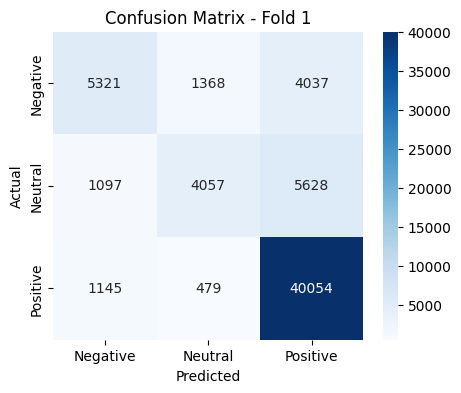

 Fold 1 Accuracy: 0.7823, F1 Score: 0.6482, AUC: 0.8820


In [38]:

    model.eval()
    all_preds, all_probs, all_true = [], [], []
    with torch.no_grad():
        for input_batch, label_batch in val_loader:
            input_batch = input_batch.to(device)
            outputs = model(input_batch)
            probs = torch.softmax(outputs, dim=1)
            preds = torch.argmax(probs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
            all_true.extend(label_batch.numpy())


    acc = accuracy_score(all_true, all_preds)
    f1 = f1_score(all_true, all_preds, average='macro')
    try:
        auc = roc_auc_score(
            label_binarize(all_true, classes=[0, 1, 2]),
            np.array(all_probs),
            multi_class='ovr'
        )
    except:
        auc = float('nan')

    acc_list.append(acc)
    f1_list.append(f1)
    auc_list.append(auc)


    cm = confusion_matrix(all_true, all_preds)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=label_encoder.classes_,
                yticklabels=label_encoder.classes_)
    plt.title(f'Confusion Matrix - Fold {fold}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

    print(f" Fold {fold} Accuracy: {acc:.4f}, F1 Score: {f1:.4f}, AUC: {auc:.4f}")
    fold += 1


In [39]:
print("\n Final 5-Fold CV Results:")
print(f"Average Accuracy: {np.mean(acc_list):.4f}")
print(f"Average F1 Score: {np.mean(f1_list):.4f}")
print(f"Average AUC: {np.mean(auc_list):.4f}")



 Final 5-Fold CV Results:
Average Accuracy: 0.7823
Average F1 Score: 0.6482
Average AUC: 0.8820
